# Introduction to logistic regression

---

#### Summary videos

- [Basic ideas of logistic regression](https://youtu.be/uYC2eLVSpI8?si=sCXSQAz7rAbQPufD) (6 minutes)

---

So far, we've dealt with regression techniques for *numerical* response variables. The process of **logistic regression** is a way of using regression on a *categorical* response variable with 2 levels.

Logistic regression is a type of **generalized linear model** --- these are regression models that first model the response variable with a probability distribution and then use a special form of multiple regression to model the *parameter(s)* of that distribution.

## Resume data

We'll be considering data from an experiment that sought to understand the influence of race and gender on job application callback rates. The study monitored job postings in Boston and Chicago for several months during 2001 and 2002 and used this to build up a set of test cases.

Over this time period, the researchers randomly generating resumes to go out to a job posting, such as years of experience and education details, to create a realistic-looking resume. They then randomly assigned a name to the resume that would communicate the applicant's gender and race. The first names chosen for the study were selected so that the names would predominantly be recognized as belonging to black or white individuals.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.stats as stats
import pandas as pd
import statsmodels.api as sm
from plotnine import *

resume = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/resume.csv')

In [ ]:
resume[['firstname', 'race', 'gender', 'received_callback']].head()

Below is a two-way table summarizing the callback rates across the `race` variable.

In [ ]:
pd.crosstab(resume['race'], resume['received_callback'], margins = True, margins_name = 'Total')

### Questions

- What can you observe from this table?
- Is it possible that this observation is due to chance?

#### Solution

- Resumes with black-sounding names appear to receive less callbacks.

- Yes, this may be due to chance, but we can perform statistical inference to investigate the significance of this observation!

## Modeling the probability of an event

Logistic regression works by representing the response variable (`received_callback` in our case) as a random variable that takes outcome $Y_i = 1$ with probability $p_i$ and outcome $Y_i = 0$ with probability $1 - p_i$.

Note the index of $i$: since each entry in the data has different features, the probability $p_i$ is *different* in each case!

We perform the **logit transformation** on these probabilities, upon which we perform (multiple) linear regression to produce a model of the form

$$ \log_e\left( \frac{p_i}{1 - p_i} \right) = \text{logit}\left( p_i \right) = \beta_0 + \beta_1 x_{1,i} + \beta_2 x_{2, i} + \cdots + \beta_k x_{k,i}. $$

Below is a graph of the `logit` function from page 373 of the textbook.

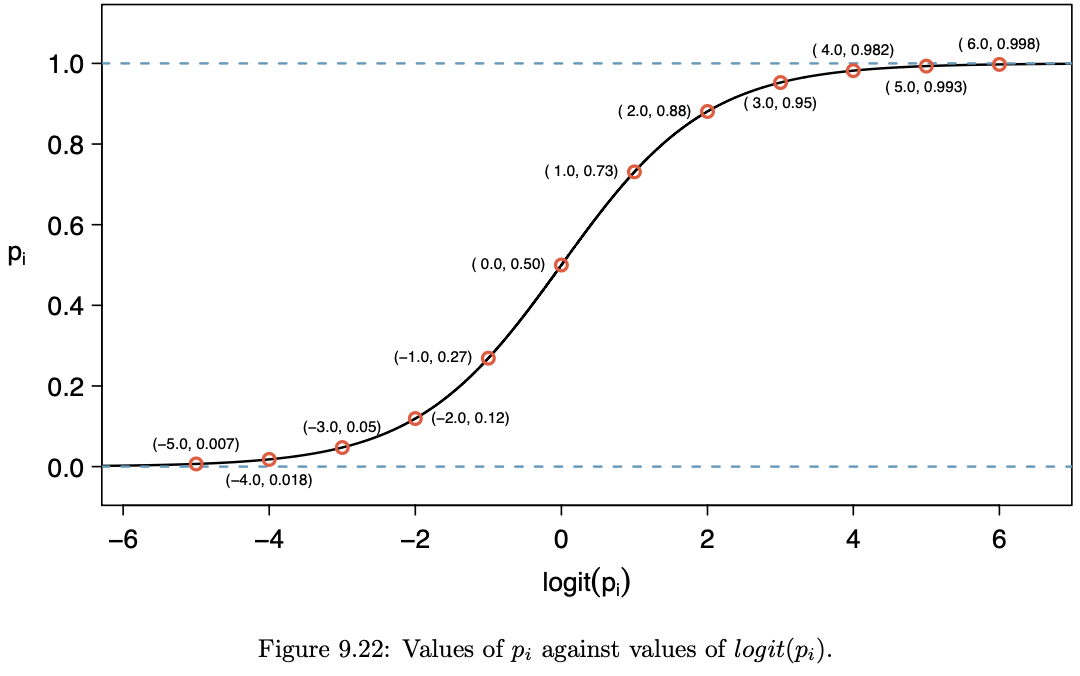

Effectively, this transformation turns the discrete outputs of $0$ and $1$ into a *range* of values representing the probability of the outputting being $0$ or $1$.

- If $\text{logit}(p_i) = 0$, then the probability of either output is 0.5.
- If $\text{logit}(p_i) > 0$, then the output is more likely to be 1.
- If $\text{logit}(p_i) < 0$, then the output is more likely to be 0.  

## Building the logistic model

We'll build up to a model that attempts to predict `received_callback` based on the following 8 varibles.

- `job_city`
- `college_degree`
- `years_experience`
- `honors`
- `military`
- `has_email_address`
- `race`
- `gender`.

Let's start by introducing a single predictor, namely `race`.

In [ ]:
log_reg = sm.formula.logit('received_callback ~ race', data = resume).fit()

print(log_reg.summary())

### Exercise

- Write out the logistic regression model from the summary output.
- If the resume had a white-sounding name, what is the probability that the resume received a callback?
- If the resume did not have a white-sounding name, what is the probability that the resume received a callbadk?

In [ ]:
# Use this function to solve for the probability from a given value
# of the logit function.

def prob_from_logit(number):
  print(np.exp(number) / (1 + np.exp(number)))

#### Solution

- The model is

$$\log_e\left(\frac{p}{1-p}\right) = -2.6748 + 0.4382\cdot\texttt{T.white} $$

- If the resume had a white-sounding name, then `T.white` is $1$. In this case, the model predicts
$$\log_e\left(\frac{p}{1-p}\right) = -2.6748 + 0.4382\cdot 1 = -2.2366.$$
So, the probability of a white-sounding name recieving a callback is predicted to be
$$\texttt{prob_from_logit}(-2.2366)\approx 0.0965.$$

- If the resume had a black-sounding name, then `T.white` is $0$. In this case, the model predicts
$$\log_e\left(\frac{p}{1-p}\right) = -2.6748 + 0.4382\cdot 0 = -2.6748.$$
So, the probability of a black-sounding name recieving a callback is predicted to be
$$\texttt{prob_from_logit}(-2.26748)\approx 0.0645.$$

Now, let's fit the larger model with all 8 of the suggested predictor variables listed above.

In [ ]:
full_log_reg = sm.formula.logit('received_callback ~ job_city + college_degree + years_experience + honors + military + has_email_address + race + gender', data = resume).fit()

print(full_log_reg.summary())

### Exercise
We can use backward elimination with the p-value approach to trim this model down. Which of the predictor variables should we eliminate first?

#### Solution
The `college_degree` variable has the largest p-value, so it would be eliminated first using this approach.

In [ ]:
trimmed_log_reg = sm.formula.logit('received_callback ~ job_city + years_experience + honors + military + has_email_address + race + gender', data = resume).fit()

print(trimmed_log_reg.summary())

### Exercise

- If we were to continue using the p-value backward elimination process, what variable would we eliminate from the model next?
- Which of the predictor variables appear to hurt a resume's chances of receiving a callback?

#### Solution

- The next variable to be eliminated would be the `gender`.

- The variables with negative coefficients seem to hurt a resume's chances for a callback, namely `T.Chicago`, `T.m`, and `military`.

### Exercise

- Use the model summarized above to estimate the probability of receiving a callback for
a job in Chicago where the candidate lists 14 years experience, no honors, no military experience, includes an email address, and has a first name that implies they are a White male.
- Repeat the previous exercise with a first name that implies they are a Black male, instead.
- Does it appear that `race` is a meaningful predictor of the callback rate?
- Can we conclude that having a Black-sounding name *causes* a decrease in callback rates on resumes?

#### Solution

- The model predicts
$$\log_e\left(\frac{p}{1-p}\right) = -2.6748 - 0.4364\cdot 1 + 0.4429 \cdot 1 - 0.1959 \cdot 1 + 0.0206 \cdot 14 + 0.7643 \cdot 0 - 0.3443 \cdot 0 + 0.2221 \cdot 1 = -2.3955.$$
So, the probability of a such a resume recieving a callback predicted to be
$$\texttt{prob_from_logit}(-2.3955)\approx 0.0835.$$

- The model predicts
$$\log_e\left(\frac{p}{1-p}\right) = -2.6748 - 0.4364\cdot 1 + 0.4429 \cdot 0 - 0.1959 \cdot 1 + 0.0206 \cdot 14 + 0.7643 \cdot 0 - 0.3443 \cdot 0 + 0.2221 \cdot 1 = -2.3955.$$
So, the probability of a such a resume recieving a callback predicted to be
$$\texttt{prob_from_logit}(-2.8384)\approx 0.0553.$$

- The p-value for `race` is $0.000$, so this appears to be a statistically significant predictor for callback rate.

- This was an *experimental study*, so we can in fact conclude that having a black-sounding name causes a decrease in callback rates on resumes.

## Model diagnostics

To fit a logistic regression model, we would like to see

- Each outcome, $Y_i$, is independent of the other ouctomes.
- Each predictor variable is linearly related to $\text{logit}(p_i)$ if the other predictors are held constant.

Due to the randomized nature of the experiment, independence is reasonable. To assess the other condition, we'd like to compare the true classification of the resumes against the model's predictions.

Below is a plot of the predicted probabilities of callback against the actual outcome of `received_callback`.

In [ ]:
X = resume[['job_city', 'years_experience', 'honors', 'military', 'has_email_address', 'race', 'gender']]
Y_hat = trimmed_log_reg.predict(X) # This returns the predicted probabilities

In [ ]:
plot = (
    ggplot(resume) +
    aes(x = Y_hat, y = 'received_callback') +
    geom_jitter(height = 0.2, alpha = 0.1) +
    labs(x = 'predicted probability') +
    xlim(0,0.35) + ylim(0,1)
)

plot

### Exercise

In the plot below, the dashed blue line represents the predicted probability of receiving a callback being equal to the actual callback rate. The data are put into buckets of width $10%$ and the red dots have $x$-coordinate equal to the average predicted probability of a callback for each bucket, while the $y$-coordinate is equal to the actual callback rate for that bucket.

- If we look at the resumes that we predicted would have a $5\%$ callback rate, do we find that about $5\%$ of them get a callback?

- In general, how well do the predicted probabilities of receiving a callback align with the actual callback rates?

- Given these observations, do you think the logistic model is reasonable?

In [ ]:
df = resume[['job_city', 'years_experience', 'honors', 'military', 'has_email_address', 'race', 'gender', 'received_callback']]
df['Y_hat'] = Y_hat

quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

for i in quantiles:
  data = df[(df['Y_hat'] < Y_hat.quantile(i)) & (df['Y_hat'] > Y_hat.quantile(i) - 0.1)]
  x_bar = data['Y_hat'].mean()
  MoE = 1.96 * data['Y_hat'].std() / np.sqrt(len(data))
  y_bar = data['received_callback'].mean()
  y_lower = y_bar - MoE
  y_upper = y_bar + MoE
  plot = plot + geom_point(aes(x = x_bar, y = y_bar), color = 'red')
  #plot = plot + geom_segment(aes(x = x_bar, xend = x_bar, y = y_lower, yend = y_upper),  color = 'red')

plot + geom_segment(aes(x = 0.0, xend = 0.3, y = 0.0, yend = 0.3), color = 'blue', linetype = 'dotted')

#### Solution

- It looks like the red dot with $x$-coordinate $0.05$ also has $y$-coordinate approximately $0.05$. So, yes, of the resumes that are predicted to have a callback rate of $5\%$, about $5\%$ of them actually received a callback.

- In general, most of the red dots appear to be on or close to the dashed blue line. This suggests that the predicted probability of a callback aligns fairly closely with the actual callback rates.

- Given these observations, the logistic fit appears reasonable. Note that we could improve our assessment by plotting *confidence intervals* for the bucketed data as on page 377 of the textbook.

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.